# Baseline search algorithm

In [1]:
import io
import os
import random
import torch
import json
import contextlib
from ultralytics import YOLO 
from mylib import myutils
from mylib import simsettings
from mylib import simtools
from mylib import yolo_patch_softmax as _
from constants import OBS_SCALE, CELL_SIDE, MAP_RESOLUTION, DISPLAY_STEP
from constants import AGENT_HEIGHT, AGENT_RADIUS 
from constants import MAX_ITER, CONFIDENCE_THRESHOLD
from constants import ACTIONS
from dotenv import load_dotenv
load_dotenv()

import habitat_sim
import habitat_sim.nav as nav
from habitat.utils.visualizations import maps
from habitat_sim.utils import common as utils

# Reload imported modules
%load_ext autoreload
%autoreload 2

# Load YOLO model
yolo_model = YOLO("yolo11x.pt")

# Initialize cuda:0 device
device = "cuda:0" if torch.cuda.is_available() else "cpu"
with contextlib.redirect_stdout(io.StringIO()):
    yolo_model = yolo_model.to(device)

In [2]:
# Load the JSON file for simulation
with open('simulation-data/simulations.json', 'r') as f:
    simulations = json.load(f)

# Simulation configuration (index selects the simulation)
simulation = simulations[5]

# Access its fields
SCENE = simulation["scene"]
TARGET_OBJECT = simulation["target_object"]
TARGET_OBJECT_ID = simulation["target_object_id"]
REAL_TARGET_LOCATION = simulation["target_object_location"]

# Load the JSON file for RGB camera intrinsics
with open('simulation-data/camera-intrinsics.json', 'r') as f:
    intrinsics = json.load(f)

# Simulator configuration
dataset_config_file = os.path.join(os.getenv("AI2THOR_DATA"), "ai2thor-hab.scene_dataset_config.json")
sim_settings = {
    "seed": 1,
    "dataset": dataset_config_file,  # Scene dataset
    "scene": SCENE,  # Scene path
    "width": 1024,  # Spatial resolution of the observations
    "height": int(1024*OBS_SCALE),
    "default_agent": 0,
    "sensor_height": AGENT_HEIGHT,  # Height of sensors in meters
    "color_sensor": True,  # RGB sensor
    "depth_sensor": True,  # Depth sensor
    "enable_physics": False,  # kinematics only
}
# Initialize the simulator
cfg = simsettings.make_cfg(sim_settings)
sim = habitat_sim.Simulator(cfg)

Renderer: NVIDIA GeForce GTX 1060 6GB/PCIe/SSE2 by NVIDIA Corporation
OpenGL version: 4.6.0 NVIDIA 535.230.02


[13:18:34:570487]:[Warning]:[Metadata] SceneDatasetAttributes.cpp(107)::addNewSceneInstanceToDataset : Dataset : 'ai2thor-hab' : Lighting Layout Attributes '/home/joaocbranco/projects/habitat-meta/ai2thor-hab/ai2thor-hab/configs/scenes/RoboTHOR/FloorPlan_Train5_2.scene_instance.json' specified in Scene Attributes but does not exist in dataset, so creating default.
MeshTools::compile(): ignoring Trade::MeshAttribute::TextureCoordinates 1 as its binding slot is already occupied by Trade::MeshAttribute::TextureCoordinates 0
[13:18:34:744981]:[Warning]:[Sim] Simulator.cpp(595)::instanceStageForSceneAttributes : The active scene does not contain semantic annotations : activeSemanticSceneID_ = 0
Trade::BasisImporter::openData(): missing orientation metadata, assuming Y down. Set the assumeYUp option to suppress this warning.
Trade::BasisImporter::image2D(): Y-flipping a compressed image that's not whole blocks, the result will be shifted by 2 pixels
Trade::BasisImporter::image2D(): Y-flippin

Using optional features:
    GL_ARB_vertex_array_object
    GL_ARB_separate_shader_objects
    GL_ARB_robustness
    GL_ARB_texture_storage
    GL_ARB_texture_view
    GL_ARB_framebuffer_no_attachments
    GL_ARB_invalidate_subdata
    GL_ARB_texture_storage_multisample
    GL_ARB_multi_bind
    GL_ARB_direct_state_access
    GL_ARB_get_texture_sub_image
    GL_ARB_texture_filter_anisotropic
    GL_KHR_debug
    GL_KHR_parallel_shader_compile
    GL_NV_depth_buffer_float
Using driver workarounds:
    no-forward-compatible-core-context
    nv-egl-incorrect-gl11-function-pointers
    no-layout-qualifiers-on-old-glsl
    nv-zero-context-profile-mask
    nv-implementation-color-read-format-dsa-broken
    nv-cubemap-inconsistent-compressed-image-size
    nv-cubemap-broken-full-compressed-image-query
    nv-compressed-block-size-in-bits


er::openData(): missing orientation metadata, assuming Y down. Set the assumeYUp option to suppress this warning.
Trade::BasisImporter::image2D(): Y-flipping a compressed image that's not whole blocks, the result will be shifted by 2 pixels
Trade::BasisImporter::image2D(): Y-flipping a compressed image that's not whole blocks, the result will be shifted by 3 pixels
Trade::BasisImporter::openData(): missing orientation metadata, assuming Y down. Set the assumeYUp option to suppress this warning.
Trade::BasisImporter::image2D(): Y-flipping a compressed image that's not whole blocks, the result will be shifted by 2 pixels
Trade::BasisImporter::image2D(): Y-flipping a compressed image that's not whole blocks, the result will be shifted by 3 pixels
Trade::BasisImporter::openData(): missing orientation metadata, assuming Y down. Set the assumeYUp option to suppress this warning.
Trade::BasisImporter::image2D(): Y-flipping a compressed image that's not whole blocks, the result will be shifted

In [ ]:
# Get the root node of the active scene graph
scene_root = sim.get_active_scene_graph().get_root_node()
scene_bb = scene_root.cumulative_bb
scene_dims = scene_bb.size()

# Define navmesh settings
navmesh_settings = habitat_sim.NavMeshSettings()
navmesh_settings.agent_height = AGENT_HEIGHT
navmesh_settings.agent_radius = AGENT_RADIUS
navmesh_settings.agent_max_climb = 0.2
navmesh_settings.agent_max_slope = 45.0
navmesh_settings.include_static_objects = True  # Include static objects in the navmesh computation

# Recompute the navmesh for the current scene
sim.recompute_navmesh(sim.pathfinder, navmesh_settings)

# Generate the top-down map --> 1 cm per pixel
topdown_map = maps.get_topdown_map(sim.pathfinder, height=0, meters_per_pixel=MAP_RESOLUTION, draw_border=True)
topdown_map = myutils.map_to_rgb(topdown_map)
topdown_map = myutils.add_axis_to_map(topdown_map)
topdown_map = myutils.retain_largest_white_chunk(topdown_map)
topdown_resolution = topdown_map.shape[:2]

# Generate the coarse map --> 30 cm per pixel (robot has radius 15 cm)
grid_map = maps.get_topdown_map(sim.pathfinder, height=0, meters_per_pixel=CELL_SIDE, draw_border=False)
grid_map = myutils.map_to_rgb(grid_map)
grid_map = myutils.retain_largest_white_chunk(grid_map)
grid_resolution = grid_map.shape[:2]

# Free positions
grid_free_cells, map_free_cells, world_free_coords = [], [], []

for x_g in range(grid_resolution[0]):   
    for y_g in range(grid_resolution[1]):
        if grid_map[x_g, y_g, 0] == 255: # White pixel
            # Convert to real world position and map position
            real_wrld_z, real_wrld_x = maps.from_grid(x_g, y_g, grid_resolution, pathfinder=sim.pathfinder)
            map_x, map_y = maps.to_grid(real_wrld_z, real_wrld_x, topdown_resolution, pathfinder=sim.pathfinder)

            # Check if the position is navigable and not occupied by an object
            if not sim.pathfinder.is_navigable([real_wrld_x, 0.0, real_wrld_z]) or not topdown_map[map_x, map_y, 0] == 255: # White pixel
                grid_map[x_g, y_g, :] = [128, 128, 128] # Grey pixel

# Filter map again to retain only the largest white chunk              
grid_map = myutils.retain_largest_white_chunk(grid_map)

for x_g in range(grid_resolution[0]):
    for y_g in range(grid_resolution[1]):
        if grid_map[x_g, y_g, 0] == 255: # White pixel
            # Convert to real world position and map position
            real_wrld_z, real_wrld_x = maps.from_grid(x_g, y_g, grid_resolution, pathfinder=sim.pathfinder)
            map_x, map_y = maps.to_grid(real_wrld_z, real_wrld_x, topdown_resolution, pathfinder=sim.pathfinder)

            # Check if the position is navigable and not occupied by an object
            if sim.pathfinder.is_navigable([real_wrld_x, 0.0, real_wrld_z]) and topdown_map[map_x, map_y, 0] == 255: # White pixel
                world_free_coords.append([real_wrld_x, 0.0, real_wrld_z])
                map_free_cells.append([map_x, map_y])
                grid_free_cells.append([x_g, y_g]) # Add grid position

# Count the number of occupiable positions
num_free_cells = len(grid_free_cells)

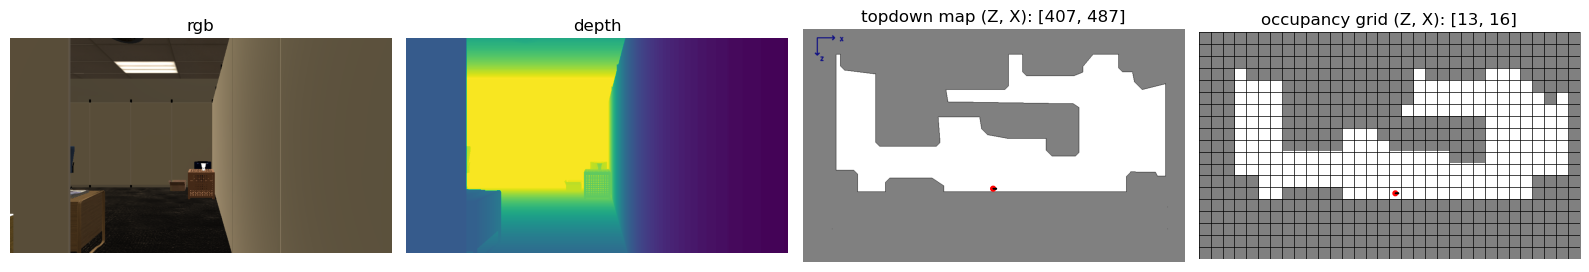

In [4]:
# Initialize an agent
agent = sim.initialize_agent(sim_settings["default_agent"])

# Sample a random position (within the possible ones)
grid_position = random.choice(grid_free_cells)
idx = grid_free_cells.index(grid_position)
world_position = world_free_coords[idx]
map_position = map_free_cells[idx]

# Sample a random yaw rotation
agent_yaw = random.choice([0, 90, 180, 270])
agent_quart = myutils.yaw_to_quaternion(agent_yaw)

# Set agent state
agent_state = habitat_sim.AgentState()
agent_state.position = world_position
agent_state.rotation = agent_quart
agent.set_state(agent_state)

# Compute agent radius in both maps
min_bounds, max_bounds = sim.pathfinder.get_bounds()
x_dim = max_bounds[0] - min_bounds[0]
topdown_radius = (AGENT_RADIUS / x_dim * topdown_resolution[0])
grid_radius = (AGENT_RADIUS / x_dim * grid_resolution[0])

# Get initial agent position tuple and radius tuple
agent_radius = (topdown_radius, grid_radius)
agent_positions = (map_position, grid_position)

# Get initial observations and maps
observations = sim.get_sensor_observations(0)
rgb = observations["color_sensor"]
depth = observations["depth_sensor"]

# Display the initial simulation state (maps + observations)
simtools.display_sim_state(rgb, depth, topdown_map, grid_map, agent_positions, agent_radius, agent_yaw)

Number of clusters: 5


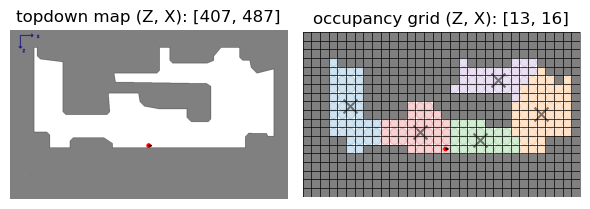

Action:  move_forward


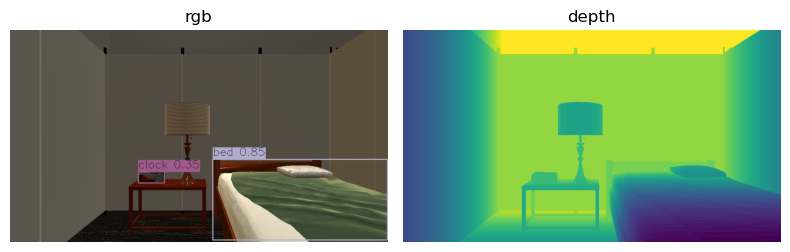

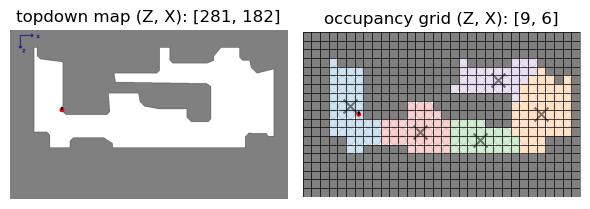

Action:  move_forward


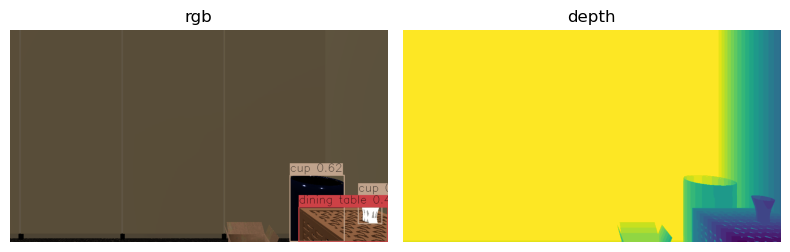

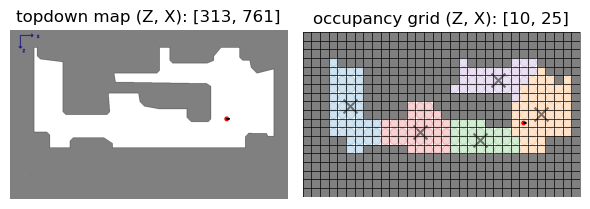

In [5]:
# Metrics initialization
target_found = False
num_actions = 0
travelled_distance = 0.0
location_error = float("inf")

# Simulation parameters
num_clusters = simtools.num_cluster_centers(num_free_cells, max_clusters=num_free_cells)
MAX_ITER = num_free_cells * 2
DISPLAY_STEP = MAX_ITER // 10  # Display every 10% of the actions
ACTIONS = ACTIONS

# Main simulation loop
while (num_clusters <= num_free_cells) and (num_actions < MAX_ITER) and (not target_found):
    
    # Cluster map
    print(f"Number of clusters: {num_clusters}")
    cluster_map = simtools.cluster_mapping(grid_free_cells, num_clusters)
    cluster_centers = simtools.get_cluster_centers(cluster_map, num_clusters)
    cluster_centers_copy = cluster_centers.copy() # For displaying logic
    simtools.display_topdown_maps_with_clusters(topdown_map, grid_map, agent_positions, agent_radius, agent_yaw, cluster_map, cluster_centers_copy)

    # Go through each cluster center
    while (cluster_centers) and (num_actions < MAX_ITER) and (not target_found):

        # Select closest cluster center
        cluster_center, path = simtools.get_closest_cluster_path(grid_position, cluster_centers, grid_free_cells)
        #print(f"Next cluster: {cluster_center} Path: {path} Distance: {CELL_SIDE * len(path)} m")

        # Move along the path 
        while (path) and (num_actions < MAX_ITER) and (not target_found):
            
            # Compute actions to move to next path cell
            action_list = simtools.compute_relative_actions(grid_position, agent_yaw, path[0], ACTIONS)

            # Go through each action in the action list
            for action in action_list:
                # Perform action
                grid_position, agent_yaw = simtools.perform_action(action, grid_position, agent_yaw)
                idx = grid_free_cells.index(grid_position)
                map_position, world_position = map_free_cells[idx], world_free_coords[idx]
                agent_positions = (map_position, grid_position)
                agent_quart = myutils.yaw_to_quaternion(agent_yaw)

                # Update metrics
                num_actions += 1
                travelled_distance += simtools.compute_travelled_distance(agent_state.position, world_position)

                # Update agent state
                agent_state.position = world_position
                agent_state.rotation = agent_quart
                agent.set_state(agent_state)

                # Get observations
                obs = sim.get_sensor_observations(0)
                rgb, depth = obs["color_sensor"], obs["depth_sensor"]

                # YOLO Prediction
                results = yolo_model.predict(source=rgb[:,:,:3], device='cuda:0', conf=0.30, iou=0.40, verbose=False, max_det=10)
                detections = simtools.parse_yolo_detections(results)
                simtools.merge_rgb_yolo_outputs(rgb, detections)
                target_found, target_bbox = simtools.was_target_found(TARGET_OBJECT_ID, detections, CONFIDENCE_THRESHOLD)

                # Display the simulation state
                if num_actions % DISPLAY_STEP == 0:
                    print("Action: ", action)
                    simtools.display_sim_observations(rgb, depth)
                    simtools.display_topdown_maps_with_clusters(topdown_map, grid_map, agent_positions, agent_radius, agent_yaw, cluster_map, cluster_centers_copy)

                # Check if target was found
                if target_found: break

            # Remove the path cell from the path
            path.pop(0)

        # Check if the target was found
        if target_found: break

        # Rotate times to get the full 360 degrees view
        for i in range(3):
            # Perform the action
            grid_position, agent_yaw = simtools.perform_action('turn_right', grid_position, agent_yaw)
            agent_quart = myutils.yaw_to_quaternion(agent_yaw)
            agent_state.rotation = agent_quart
            agent.set_state(agent_state)

            # Update metrics
            num_actions += 1

            # Get observations
            obs = sim.get_sensor_observations(0)
            rgb, depth = obs["color_sensor"], obs["depth_sensor"]

            # YOLO Prediction
            results = yolo_model.predict(source=rgb[:,:,:3], device='cuda:0', conf=0.30, iou=0.40, verbose=False, max_det=10)
            detections = simtools.parse_yolo_detections(results)
            simtools.merge_rgb_yolo_outputs(rgb, detections)
            target_found, target_bbox = simtools.was_target_found(TARGET_OBJECT_ID, detections, CONFIDENCE_THRESHOLD)
            
            # Display the simulation state
            if num_actions % DISPLAY_STEP == 0:
                print("Action: ", 'turn_right')
                simtools.display_sim_observations(rgb, depth)
                simtools.display_topdown_maps_with_clusters(topdown_map, grid_map, agent_positions, agent_radius, agent_yaw, cluster_map, cluster_centers_copy)

            # If the target object is found, break
            if target_found: break 

        # Remove the grid cluster center from the list
        cluster_centers.remove(cluster_center)

    # Double the number of clusters
    num_clusters *= 2


Target object <bowl> found after 77 actions!
Found location: [    -1.8935     0.19663     -4.4329]
Real location: [-1.8632761240005493, 0.7469968199729919, -4.524569988250732]


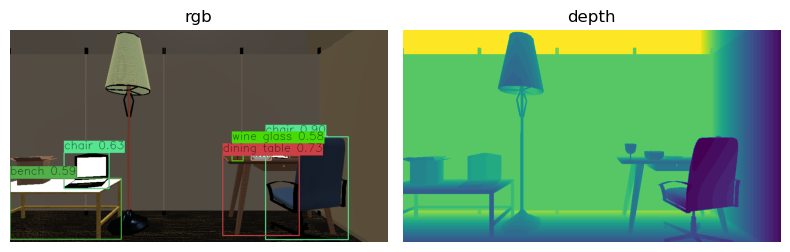

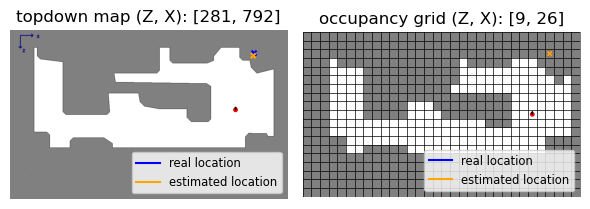

Number of actions: 77
Travelled distance: 15.33 m
Computed localization error: 0.097 m


In [6]:
# Target found or not
if target_found:
    # Real world position 
    center_x, center_y = simtools.get_box_center(target_bbox)
    depth_value = depth[center_y, center_x]
    target_object_position = simtools.compute_real_world_position_from_pixel(agent_state.position, agent_state.rotation, depth_value, center_x, center_y, intrinsics)

    # location_error to the target location
    location_error = simtools.compute_location_error(target_object_position, REAL_TARGET_LOCATION)

    # Convert to 2D coordinates
    target_map_position, target_grid_position = simtools.get_2d_coords(target_object_position, topdown_resolution, grid_resolution, sim.pathfinder)
    target_real_map_position, target_real_grid_position = simtools.get_2d_coords(REAL_TARGET_LOCATION, topdown_resolution, grid_resolution, sim.pathfinder)
    target_2d_coords = (target_map_position, target_grid_position)
    target_real_2d_coords = (target_real_map_position, target_real_grid_position)
    target_coords = (target_real_2d_coords, target_2d_coords)

    # Show info
    print(f"\nTarget object <{TARGET_OBJECT}> found after {num_actions} actions!")
    print(f"Found location: {target_object_position}")
    print(f"Real location: {REAL_TARGET_LOCATION}")
    simtools.display_sim_observations(rgb, depth)
    simtools.display_topdown_maps_with_target(topdown_map, grid_map, agent_positions, agent_radius, agent_yaw, target_coords)
else:
    print(f"\nTarget object <{TARGET_OBJECT}> not found after {MAX_ITER} actions!")
    print(f"Real location: {REAL_TARGET_LOCATION}")

# Display simulation metrics
print(f"Number of actions: {num_actions}")
print(f"Travelled distance: {travelled_distance:.2f} m")
print(f"Computed localization error: {location_error:.3f} m")